In [2]:
import json
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, make_scorer, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, cohen_kappa_score, roc_auc_score, confusion_matrix, plot_precision_recall_curve, plot_roc_curve, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
import tensorflow as tf

# FCPython is a set of functions distributed as part of the code for Uppsala University's 
# Mathematical Modelling of Football course (https://uppsala.instructure.com/courses/28112)
# which was produced based on the content put out by FCPython (https://fcpython.com/)
from FCPython import createPitch

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

![Statsbomb Logo](md_imgs/SB_Regular.png)


This notebook uses Statsbomb's open data (https://github.com/statsbomb/open-data) which is a rich and varied datasource that makes doing this type of work much easier (or even possible at all) than iit otherwise would have been.

Aspects such as loading the data in, and the FCPython module, were taken from content delivered by David Sumpter on Uppsala University's Mathematical Modelling of Football course (https://uppsala.instructure.com/courses/28112). This is an excellent course to get started on the basics of Football Analytics. It has really interesting lectures, as well as lots of great code which is worth looking through even if you aren't interested in the lectures. Best of all its free!

## Load all LaLiga data

In [3]:
competition_id=11
season_ids = [37,38,40,41,21,22,23,24,25,26,27,2,1,4,42]
#Load the list of matches for this competition

all_matches = pd.DataFrame(None)

for season_id in season_ids:
    with open(f'C:/Users/matth/Google Drive/Data Science/Football Analytics/SoccermaticsForPython-master/Statsbomb/data/matches/{str(competition_id)}/{str(season_id)}.json', encoding='utf-8') as f:
        matches = json.load(f)
        season_json = pd.json_normalize(matches, sep = "_")
        all_matches = pd.concat([all_matches,season_json],axis=0)
    
print(all_matches.shape)


# Although I haven't used it here, I find it useful to keep this line of code to hand in case I wanted to focus on games
# between specific teams

#chosen = all_matches[((all_matches['home_team_home_team_name'] == '[name here]') & (all_matches['away_team_away_team_name'] == '[name here]'))
#          |((all_matches['home_team_home_team_name'] == '[name here]') & (all_matches['away_team_away_team_name'] == '[name here]'))]


chosen_ids = all_matches['match_id']
chosen_id_season = all_matches['season_season_name']

id_iterator = zip(chosen_ids,chosen_id_season)
prev_season = ''
first_pass=True
seasons_list = []
for id, season in id_iterator:

    with open("C:/Users/matth/Google Drive/Data Science/Football Analytics/SoccermaticsForPython-master/Statsbomb/data/events/"+str(id)+".json", encoding='utf-8') as f:
        events = json.load(f)
        matches = pd.json_normalize(events, sep = "_")
        if first_pass==True:
            cols = matches.columns
            all_games = pd.DataFrame([],columns=cols)
            first_pass=False
        matches = matches[matches.type_name == 'Pass']
        matches['season'] = season
        seasons_list.append(matches)
        if season != prev_season:
            print(season)
            prev_season = season
            print(f'Rows so far: {matches.shape[0]}')

all_games = pd.concat(seasons_list)
print(all_games.shape)
all_games.head()

(459, 40)
2004/2005
Rows so far: 922
2005/2006
Rows so far: 875
2007/2008
Rows so far: 1032
2008/2009
Rows so far: 895
2009/2010
Rows so far: 1009
2010/2011
Rows so far: 1179
2011/2012
Rows so far: 898
2012/2013
Rows so far: 1241
2013/2014
Rows so far: 1028
2014/2015
Rows so far: 1064
2015/2016
Rows so far: 1062
2016/2017
Rows so far: 878
2017/2018
Rows so far: 1019
2018/2019
Rows so far: 1195
2019/2020
Rows so far: 1168
(481121, 148)


,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_id,team_name,tactics_formation,tactics_lineup,related_events,location,player_id,player_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_type_id,pass_type_name,pass_body_part_id,pass_body_part_name,carry_end_location,under_pressure,dribble_outcome_id,dribble_outcome_name,duel_outcome_id,duel_outcome_name,duel_type_id,duel_type_name,pass_outcome_id,pass_outcome_name,ball_receipt_outcome_id,ball_receipt_outcome_name,out,clearance_head,clearance_body_part_id,clearance_body_part_name,pass_switch,pass_outswinging,pass_technique_id,pass_technique_name,counterpress,pass_assisted_shot_id,pass_shot_assist,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_first_time,shot_outcome_id,shot_outcome_name,shot_type_id,shot_type_name,shot_body_part_id,shot_body_part_name,shot_technique_id,shot_technique_name,shot_freeze_frame,goalkeeper_end_location,goalkeeper_position_id,goalkeeper_position_name,goalkeeper_type_id,goalkeeper_type_name,off_camera,clearance_aerial_won,interception_outcome_id,interception_outcome_name,clearance_left_foot,pass_aerial_won,pass_cross,foul_committed_advantage,foul_won_advantage,clearance_right_foot,dribble_overrun,foul_committed_type_id,foul_committed_type_name,pass_through_ball,goalkeeper_outcome_id,goalkeeper_outcome_name,foul_committed_card_id,foul_committed_card_name,foul_won_defensive,ball_recovery_recovery_failure,dribble_nutmeg,pass_goal_assist,shot_one_on_one,goalkeeper_technique_id,goalkeeper_technique_name,pass_inswinging,pass_no_touch,substitution_outcome_id,substitution_outcome_name,substitution_replacement_id,substitution_replacement_name,goalkeeper_body_part_id,goalkeeper_body_part_name,foul_committed_offensive,pass_miscommunication,ball_recovery_offensive,injury_stoppage_in_chain,50_50_outcome_id,50_50_outcome_name,pass_cut_back,season,pass_deflected,miscontrol_aerial_won,block_deflection,foul_committed_penalty,foul_won_penalty,shot_aerial_won,shot_saved_to_post,goalkeeper_shot_saved_to_post,bad_behaviour_card_id,bad_behaviour_card_name,block_save_block,shot_deflected,block_offensive,shot_redirect,pass_straight,goalkeeper_punched_out,goalkeeper_success_in_play,dribble_no_touch,shot_open_goal,clearance_other,shot_saved_off_target,goalkeeper_shot_saved_off_target,half_start_late_video_start,player_off_permanent,goalkeeper_saved_to_post,goalkeeper_lost_out,shot_follows_dribble,goalkeeper_success_out,goalkeeper_lost_in_play,half_end_early_video_end,pass_backheel
4,6c222ac8-0537-4dae-8e1c-601fe0b582b0,5,1,00:00:00.934,0,0,2,0.704954,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[79d0ce33-ca5c-4b0e-a62d-778e9a7b00a9],"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",23.0,Center Forward,5216.0,Andrés Iniesta Luján,1.702939,1.629552,1.0,Ground Pass,"[59.9, 41.7]",65.0,Kick Off,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004/2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,44acb6bc-b633-4946-a960-b53ab64940cb,8,1,00:00:01.679,0,1,2,1.015002,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[99323b79-0730-4b36-9586-2b58eff7fdff],"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,17.0,Right Wing,25879.0,Ronaldo de Assis Moreira,10.945775,3.050106,1.0,Ground Pass,"[49.3, 40.7]",NaN,NaN,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

Check which seasons we have and have many events per season

In [4]:
rolling_count_df = pd.DataFrame(all_games.season.value_counts())
rolling_count_df.reset_index(inplace=True)
rolling_count_df.columns = ['season','count']
rolling_count_df['season'] = pd.Categorical(rolling_count_df['season'], ['2004/2005', '2005/2006', '2007/2008', '2008/2009', '2009/2010',
       '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015',
       '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020'])
rolling_count_df.sort_values("season",inplace=True)
rolling_count_df.head()

,season,count
14,2004/2005,6253
13,2005/2006,15492
12,2007/2008,27425
11,2008/2009,29324
7,2009/2010,35445


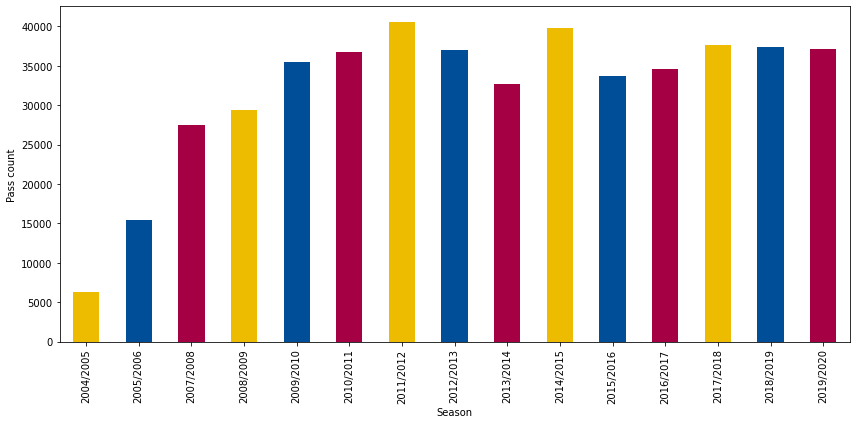

In [5]:
cmap = sns.color_palette("Blues")
barca_colors = ['#EDBB00','#004D98','#A50044']
rolling_count_df.plot(x='season', y='count', kind = 'bar', color = barca_colors, legend=None )
fig = plt.gcf()
fig.set_size_inches(12, 6)
plt.ylabel('Pass count')
plt.xlabel('Season')
plt.tight_layout()
plt.savefig('rolling_season_passes.png')

The trend of decreasing events per season is expected as Messi debuted in 04/05, and gradually became a mainstay in the team

In [6]:
passes = all_games.copy()

In [7]:
passes.head()

,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_id,team_name,tactics_formation,tactics_lineup,related_events,location,player_id,player_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_type_id,pass_type_name,pass_body_part_id,pass_body_part_name,carry_end_location,under_pressure,dribble_outcome_id,dribble_outcome_name,duel_outcome_id,duel_outcome_name,duel_type_id,duel_type_name,pass_outcome_id,pass_outcome_name,ball_receipt_outcome_id,ball_receipt_outcome_name,out,clearance_head,clearance_body_part_id,clearance_body_part_name,pass_switch,pass_outswinging,pass_technique_id,pass_technique_name,counterpress,pass_assisted_shot_id,pass_shot_assist,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_first_time,shot_outcome_id,shot_outcome_name,shot_type_id,shot_type_name,shot_body_part_id,shot_body_part_name,shot_technique_id,shot_technique_name,shot_freeze_frame,goalkeeper_end_location,goalkeeper_position_id,goalkeeper_position_name,goalkeeper_type_id,goalkeeper_type_name,off_camera,clearance_aerial_won,interception_outcome_id,interception_outcome_name,clearance_left_foot,pass_aerial_won,pass_cross,foul_committed_advantage,foul_won_advantage,clearance_right_foot,dribble_overrun,foul_committed_type_id,foul_committed_type_name,pass_through_ball,goalkeeper_outcome_id,goalkeeper_outcome_name,foul_committed_card_id,foul_committed_card_name,foul_won_defensive,ball_recovery_recovery_failure,dribble_nutmeg,pass_goal_assist,shot_one_on_one,goalkeeper_technique_id,goalkeeper_technique_name,pass_inswinging,pass_no_touch,substitution_outcome_id,substitution_outcome_name,substitution_replacement_id,substitution_replacement_name,goalkeeper_body_part_id,goalkeeper_body_part_name,foul_committed_offensive,pass_miscommunication,ball_recovery_offensive,injury_stoppage_in_chain,50_50_outcome_id,50_50_outcome_name,pass_cut_back,season,pass_deflected,miscontrol_aerial_won,block_deflection,foul_committed_penalty,foul_won_penalty,shot_aerial_won,shot_saved_to_post,goalkeeper_shot_saved_to_post,bad_behaviour_card_id,bad_behaviour_card_name,block_save_block,shot_deflected,block_offensive,shot_redirect,pass_straight,goalkeeper_punched_out,goalkeeper_success_in_play,dribble_no_touch,shot_open_goal,clearance_other,shot_saved_off_target,goalkeeper_shot_saved_off_target,half_start_late_video_start,player_off_permanent,goalkeeper_saved_to_post,goalkeeper_lost_out,shot_follows_dribble,goalkeeper_success_out,goalkeeper_lost_in_play,half_end_early_video_end,pass_backheel
4,6c222ac8-0537-4dae-8e1c-601fe0b582b0,5,1,00:00:00.934,0,0,2,0.704954,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[79d0ce33-ca5c-4b0e-a62d-778e9a7b00a9],"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",23.0,Center Forward,5216.0,Andrés Iniesta Luján,1.702939,1.629552,1.0,Ground Pass,"[59.9, 41.7]",65.0,Kick Off,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004/2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,44acb6bc-b633-4946-a960-b53ab64940cb,8,1,00:00:01.679,0,1,2,1.015002,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[99323b79-0730-4b36-9586-2b58eff7fdff],"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,17.0,Right Wing,25879.0,Ronaldo de Assis Moreira,10.945775,3.050106,1.0,Ground Pass,"[49.3, 40.7]",NaN,NaN,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

Let's have a quick look at what types of passes we have

In [8]:
passes.pass_type_name.unique()

array(['Kick Off', nan, 'Throw-in', 'Corner', 'Goal Kick', 'Recovery',
       'Free Kick', 'Interception'], dtype=object)

Working assumption based on this result is that NaN represents where the pass is a 'normal' pass

Now let's look at what variables we have in our dataset. This probably isn't the best way to do this, as Statsbomb have excellent documentation covering their data (https://github.com/statsbomb/open-data > Doc > Open Data Events PDF). Their PDF gives all the columns, possible values in each, as well as a brief explanation of what that column shows as sometimes the field names aren't understandably slightly ambigious sometimes. I find it helpful to have a list of all columns which I might like to use and can easily copy and paste from.

In [9]:
print(list(passes.columns))

['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession', 'duration', 'type_id', 'type_name', 'possession_team_id', 'possession_team_name', 'play_pattern_id', 'play_pattern_name', 'team_id', 'team_name', 'tactics_formation', 'tactics_lineup', 'related_events', 'location', 'player_id', 'player_name', 'position_id', 'position_name', 'pass_recipient_id', 'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id', 'pass_height_name', 'pass_end_location', 'pass_type_id', 'pass_type_name', 'pass_body_part_id', 'pass_body_part_name', 'carry_end_location', 'under_pressure', 'dribble_outcome_id', 'dribble_outcome_name', 'duel_outcome_id', 'duel_outcome_name', 'duel_type_id', 'duel_type_name', 'pass_outcome_id', 'pass_outcome_name', 'ball_receipt_outcome_id', 'ball_receipt_outcome_name', 'out', 'clearance_head', 'clearance_body_part_id', 'clearance_body_part_name', 'pass_switch', 'pass_outswinging', 'pass_technique_id', 'pass_technique_name', 'counterpress', 'pass_assist

Downselect to only include columns which we are interested in

Additionally, we filter out any passes where a pass recipient isn't named - this removes ~30k passes. We perform this step because having the end coordinates of the pass is an important set of features to have, as it also means we have a pass length and angle.

In [10]:
passes_outcome = passes[~passes.pass_recipient_name.isna()][['season','related_events', 'location', 'player_id', 'player_name','team_name','position_id', 'position_name', 'pass_recipient_id', 'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id', 'pass_height_name', 'pass_end_location', 'pass_body_part_id', 'pass_body_part_name', 'pass_type_id', 'pass_type_name','pass_outcome_name','under_pressure','pass_switch','pass_outswinging','pass_technique_name','pass_through_ball','pass_inswinging','pass_no_touch','pass_cut_back','pass_straight']]
print(passes_outcome.shape)
passes_outcome.head()

(454451, 29)


,season,related_events,location,player_id,player_name,team_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_body_part_id,pass_body_part_name,pass_type_id,pass_type_name,pass_outcome_name,under_pressure,pass_switch,pass_outswinging,pass_technique_name,pass_through_ball,pass_inswinging,pass_no_touch,pass_cut_back,pass_straight
4,2004/2005,[79d0ce33-ca5c-4b0e-a62d-778e9a7b00a9],"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",Barcelona,23.0,Center Forward,5216.0,Andrés Iniesta Luján,1.702939,1.629552,1.0,Ground Pass,"[59.9, 41.7]",40.0,Right Foot,65.0,Kick Off,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2004/2005,[99323b79-0730-4b36-9586-2b58eff7fdff],"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,Barcelona,17.0,Right Wing,25879.0,Ronaldo de Assis Moreira,10.945775,3.050106,1.0,Ground Pass,"[49.3, 40.7]",40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,2004/2005,[95495331-8b20-4c55-9e41-be3e53f33e02],"[50.6, 40.6]",25879.0,Ronaldo de Assis Moreira,Barcelona,21.0,Left Wing,17797.0,Giovanni van Bronckhorst,36.523144,-1.535195,1.0,Ground Pass,"[51.9, 4.1]",40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2004/2005,"[947bac92-19d0-4372-89f2-2fc14264e379, b1f9b18...","[49.7, 4.8]",17797.0,Giovanni van Bronckhorst,Barcelona,6.0,Left Back,25873.0,Oleguer Presas Renom,23.231230,2.720309,1.0,Ground Pass,"[28.5, 14.3]",38.0,Left Foot,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,2004/2005,[4f116936-4723-4c53-be69-ec3c04f2e373],"[25.4, 18.8]",25873.0,Oleguer Presas Renom,Barcelona,3.0,Right Center Back,20125.0,Carles Puyol i Saforcada,24.955961,1.401695,1.0,Ground Pass,"[29.6, 43.4]",40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Check how the pass outcomes are encoded

In [11]:
passes_outcome.pass_outcome_name.unique()

array([nan, 'Incomplete', 'Out', 'Pass Offside', 'Unknown',
       'Injury Clearance'], dtype=object)

Similar to pass_type earlier, a NaN value is a successful pass and all others are unsuccessful. As such, we'll populate those NaNs with 'Success' to make it more obvious

In [12]:
passes_outcome['pass_outcome_name'] = passes_outcome['pass_outcome_name'].fillna('Success',axis=0)

In [13]:
pass_outcome_pie = pd.DataFrame(passes_outcome.pass_outcome_name.value_counts())
pass_outcome_pie.reset_index(inplace=True)
pass_outcome_pie.columns = ['outcome','count']
pass_outcome_pie.head(10)

,outcome,count
0,Success,394118
1,Incomplete,51769
2,Out,4809
3,Pass Offside,2343
4,Unknown,1404
5,Injury Clearance,8


In [14]:
pass_outcome_pie = pd.DataFrame([['Success',394118],['Incomplete',56578],['To Be Removed',3755]])
pass_outcome_pie.columns = ['outcome','count']
pass_outcome_pie.head()

,outcome,count
0,Success,394118
1,Incomplete,56578
2,To Be Removed,3755


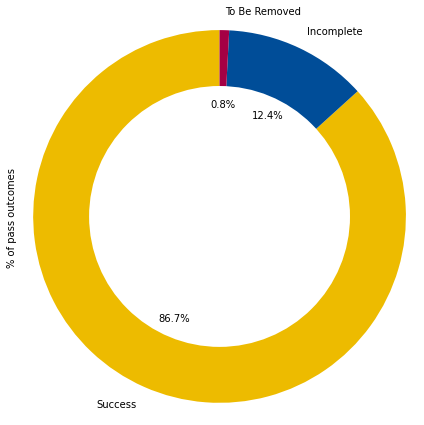

In [15]:
fig1, ax1 = plt.subplots()
ax1.pie(pass_outcome_pie['count'].values, colors = barca_colors, labels=pass_outcome_pie['outcome'].values, autopct='%1.1f%%', startangle=90)

#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')  
plt.ylabel('% of pass outcomes')
fig = plt.gcf()
fig.set_size_inches(6, 6)
plt.tight_layout()
plt.savefig('pass_outcome_pie.png')

We then remove passes which are offside, or unknown, as they're both types which are ambigious in terms of a players passing ability. Injury clearence is also removed as thats a deliberate failed pass.

In [16]:
passes_outcome_fin = passes_outcome[(passes_outcome.pass_outcome_name != 'Pass Offside')
                                    &(passes_outcome.pass_outcome_name != 'Unknown')
                                    &(passes_outcome.pass_outcome_name != 'Injury Clearance')]
print(passes_outcome_fin.shape)

(450696, 29)


Next we rename the non-Success values to a consistent value, and check what our target column looks like now

In [17]:
passes_outcome_fin['pass_outcome'] = np.where((passes_outcome_fin['pass_outcome_name'] == 'Incomplete') | (passes_outcome_fin['pass_outcome_name'] == 'Out') | (passes_outcome_fin['pass_outcome_name'] == 'Injury Clearance'),'Unsuccessful',passes_outcome_fin['pass_outcome_name'])
passes_outcome_fin['pass_outcome'].value_counts()

<ipython-input-17-9078aa7cc1c2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin['pass_outcome'] = np.where((passes_outcome_fin['pass_outcome_name'] == 'Incomplete') | (passes_outcome_fin['pass_outcome_name'] == 'Out') | (passes_outcome_fin['pass_outcome_name'] == 'Injury Clearance'),'Unsuccessful',passes_outcome_fin['pass_outcome_name'])


Success         394118
Unsuccessful     56578
Name: pass_outcome, dtype: int64

In [18]:
# Drop some values are duplicate (most are IDs where a name is also given)
passes_outcome_fin.drop(['related_events','position_id','pass_recipient_id','position_name','pass_recipient_name','pass_height_id','pass_body_part_id','pass_type_id','pass_outcome_name','pass_technique_name'],axis=1,inplace=True)
passes_outcome_fin.head()

C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:4167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,season,location,player_id,player_name,team_name,pass_length,pass_angle,pass_height_name,pass_end_location,pass_body_part_name,pass_type_name,under_pressure,pass_switch,pass_outswinging,pass_through_ball,pass_inswinging,pass_no_touch,pass_cut_back,pass_straight,pass_outcome
4,2004/2005,"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",Barcelona,1.702939,1.629552,Ground Pass,"[59.9, 41.7]",Right Foot,Kick Off,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success
7,2004/2005,"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,Barcelona,10.945775,3.050106,Ground Pass,"[49.3, 40.7]",Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success
10,2004/2005,"[50.6, 40.6]",25879.0,Ronaldo de Assis Moreira,Barcelona,36.523144,-1.535195,Ground Pass,"[51.9, 4.1]",Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success
14,2004/2005,"[49.7, 4.8]",17797.0,Giovanni van Bronckhorst,Barcelona,23.231230,2.720309,Ground Pass,"[28.5, 14.3]",Left Foot,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success
17,2004/2005,"[25.4, 18.8]",25873.0,Oleguer Presas Renom,Barcelona,24.955961,1.401695,Ground Pass,"[29.6, 43.4]",Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success


Next we want to split out the x and y coordinates of the pass start and end locations so they can be used as features

In [19]:
passes_outcome_fin[['pass_start_x','pass_start_y']] = pd.DataFrame(passes_outcome_fin.location.to_list(),index = passes_outcome_fin.index)
passes_outcome_fin[['pass_end_x','pass_end_y']] = pd.DataFrame(passes_outcome_fin.pass_end_location.to_list(),index = passes_outcome_fin.index)

passes_outcome_fin.drop(['location','pass_end_location'],axis=1,inplace=True)
passes_outcome_fin.head()

C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:3069: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]
C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:4167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,season,player_id,player_name,team_name,pass_length,pass_angle,pass_height_name,pass_body_part_name,pass_type_name,under_pressure,pass_switch,pass_outswinging,pass_through_ball,pass_inswinging,pass_no_touch,pass_cut_back,pass_straight,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y
4,2004/2005,19298.0,"Samuel Eto""o Fils",Barcelona,1.702939,1.629552,Ground Pass,Right Foot,Kick Off,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,60.0,40.0,59.9,41.7
7,2004/2005,5216.0,Andrés Iniesta Luján,Barcelona,10.945775,3.050106,Ground Pass,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,60.2,39.7,49.3,40.7
10,2004/2005,25879.0,Ronaldo de Assis Moreira,Barcelona,36.523144,-1.535195,Ground Pass,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,50.6,40.6,51.9,4.1
14,2004/2005,17797.0,Giovanni van Bronckhorst,Barcelona,23.231230,2.720309,Ground Pass,Left Foot,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,49.7,4.8,28.5,14.3
17,2004/2005,25873.0,Oleguer Presas Renom,Barcelona,24.955961,1.401695,Ground Pass,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,25.4,18.8,29.6,43.4


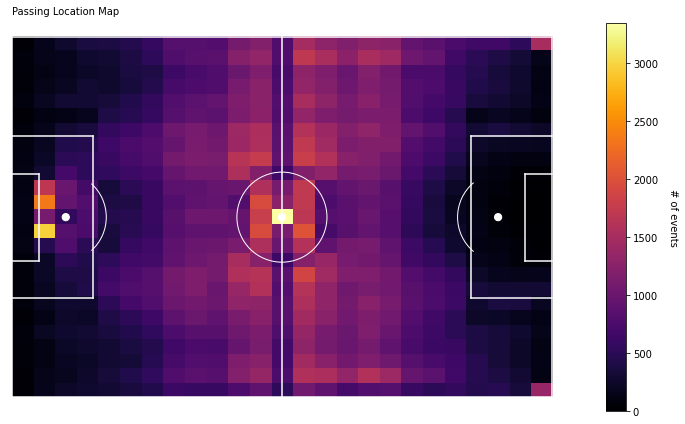

In [20]:
pitchLengthX=120
pitchWidthY=80
#Make a histogram of passes
H_Pass=np.histogram2d(passes_outcome_fin['pass_start_y'], passes_outcome_fin['pass_start_x'],bins=25,range=[[0, pitchWidthY],[0, pitchLengthX]])

number_of_matches = len(chosen_ids)

from FCPython import createPitch
(fig,ax) = createPitch(pitchLengthX,pitchWidthY,'yards','white')
pos=ax.imshow(H_Pass[0], extent=[0,120,0,80], aspect='auto',cmap=plt.cm.inferno)
cbar = fig.colorbar(pos, ax=ax,fraction=0.035, pad=0.04)
cbar.ax.set_ylabel('# of events', rotation=270, labelpad=20)
#ax.set_title('Danger passes per match by ' + team_required)
plt.xlim((-1,125))
plt.ylim((83,-3))
plt.tight_layout()
plt.gca().set_aspect('equal', adjustable='box')
plt.text(0,-5,'Passing Location Map')
fig.set_facecolor("#FFFFFF")
fig.set_size_inches(12, 6)
plt.tight_layout()
plt.savefig('passing_location_heatmap.png')


Next, I decided to scale the x and y coordinates. While not strictly necessary, I find it makes things more readable as you don't need to know the maximum values in either X or Y (for Statsbomb the max X is 120 and max Y is 80). I've tested and this scaling doesn't affect the outcome of the final chosen model

In [21]:
scaler = MinMaxScaler()

passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']] = scaler.fit_transform(passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']])
passes_outcome_fin.head()

<ipython-input-21-abe8d5606031>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']] = scaler.fit_transform(passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']])
C:\Users\matth\anaconda3\lib\site-packages\pandas\core\indexing.py:1734: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value[:, i].tolist())


,season,player_id,player_name,team_name,pass_length,pass_angle,pass_height_name,pass_body_part_name,pass_type_name,under_pressure,pass_switch,pass_outswinging,pass_through_ball,pass_inswinging,pass_no_touch,pass_cut_back,pass_straight,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y
4,2004/2005,19298.0,"Samuel Eto""o Fils",Barcelona,1.702939,1.629552,Ground Pass,Right Foot,Kick Off,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,0.495861,0.494424,0.495033,0.514851
7,2004/2005,5216.0,Andrés Iniesta Luján,Barcelona,10.945775,3.050106,Ground Pass,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,0.497517,0.490706,0.407285,0.502475
10,2004/2005,25879.0,Ronaldo de Assis Moreira,Barcelona,36.523144,-1.535195,Ground Pass,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,0.418046,0.501859,0.428808,0.049505
14,2004/2005,17797.0,Giovanni van Bronckhorst,Barcelona,23.231230,2.720309,Ground Pass,Left Foot,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,0.410596,0.058240,0.235099,0.175743
17,2004/2005,25873.0,Oleguer Presas Renom,Barcelona,24.955961,1.401695,Ground Pass,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Success,0.209437,0.231722,0.244205,0.535891


Replace NaN values with some strings, before One Hot Encoding the categorical columns (not filling these in would mean they don't get represented in OHE, so this is an important and useful step)

In [22]:
passes_outcome_fin['pass_type_name'] = passes_outcome_fin['pass_type_name'].fillna('Normal')
passes_outcome_fin['under_pressure'] = passes_outcome_fin['under_pressure'].fillna('False')
passes_outcome_fin['pass_switch'] = passes_outcome_fin['pass_switch'].fillna('False')
passes_outcome_fin['pass_outswinging'] = passes_outcome_fin['pass_outswinging'].fillna('False')
passes_outcome_fin['pass_through_ball'] = passes_outcome_fin['pass_through_ball'].fillna('False')
passes_outcome_fin['pass_inswinging'] = passes_outcome_fin['pass_inswinging'].fillna('False')
passes_outcome_fin['pass_no_touch'] = passes_outcome_fin['pass_no_touch'].fillna('False')
passes_outcome_fin['pass_cut_back'] = passes_outcome_fin['pass_cut_back'].fillna('False')
passes_outcome_fin['pass_straight'] = passes_outcome_fin['pass_straight'].fillna('False')
passes_outcome_fin.head()

<ipython-input-22-51c92c7ad2ca>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin['pass_type_name'] = passes_outcome_fin['pass_type_name'].fillna('Normal')
<ipython-input-22-51c92c7ad2ca>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin['under_pressure'] = passes_outcome_fin['under_pressure'].fillna('False')
<ipython-input-22-51c92c7ad2ca>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

,season,player_id,player_name,team_name,pass_length,pass_angle,pass_height_name,pass_body_part_name,pass_type_name,under_pressure,pass_switch,pass_outswinging,pass_through_ball,pass_inswinging,pass_no_touch,pass_cut_back,pass_straight,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y
4,2004/2005,19298.0,"Samuel Eto""o Fils",Barcelona,1.702939,1.629552,Ground Pass,Right Foot,Kick Off,False,False,False,False,False,False,False,False,Success,0.495861,0.494424,0.495033,0.514851
7,2004/2005,5216.0,Andrés Iniesta Luján,Barcelona,10.945775,3.050106,Ground Pass,Right Foot,Normal,False,False,False,False,False,False,False,False,Success,0.497517,0.490706,0.407285,0.502475
10,2004/2005,25879.0,Ronaldo de Assis Moreira,Barcelona,36.523144,-1.535195,Ground Pass,Right Foot,Normal,False,False,False,False,False,False,False,False,Success,0.418046,0.501859,0.428808,0.049505
14,2004/2005,17797.0,Giovanni van Bronckhorst,Barcelona,23.231230,2.720309,Ground Pass,Left Foot,Normal,True,False,False,False,False,False,False,False,Success,0.410596,0.058240,0.235099,0.175743
17,2004/2005,25873.0,Oleguer Presas Renom,Barcelona,24.955961,1.401695,Ground Pass,Right Foot,Normal,False,False,False,False,False,False,False,False,Success,0.209437,0.231722,0.244205,0.535891


In [23]:
passes_outcome_fin = pd.get_dummies(passes_outcome_fin,columns=['pass_height_name','pass_body_part_name','pass_type_name','under_pressure','pass_switch','pass_outswinging','pass_through_ball','pass_inswinging','pass_no_touch','pass_cut_back','pass_straight'])
passes_outcome_fin.head()

,season,player_id,player_name,team_name,pass_length,pass_angle,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y,pass_height_name_Ground Pass,pass_height_name_High Pass,pass_height_name_Low Pass,pass_body_part_name_Drop Kick,pass_body_part_name_Head,pass_body_part_name_Keeper Arm,pass_body_part_name_Left Foot,pass_body_part_name_No Touch,pass_body_part_name_Other,pass_body_part_name_Right Foot,pass_type_name_Corner,pass_type_name_Free Kick,pass_type_name_Goal Kick,pass_type_name_Interception,pass_type_name_Kick Off,pass_type_name_Normal,pass_type_name_Recovery,pass_type_name_Throw-in,under_pressure_True,under_pressure_False,pass_switch_True,pass_switch_False,pass_outswinging_True,pass_outswinging_False,pass_through_ball_True,pass_through_ball_False,pass_inswinging_True,pass_inswinging_False,pass_no_touch_True,pass_no_touch_False,pass_cut_back_True,pass_cut_back_False,pass_straight_True,pass_straight_False
4,2004/2005,19298.0,"Samuel Eto""o Fils",Barcelona,1.702939,1.629552,Success,0.495861,0.494424,0.495033,0.514851,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
7,2004/2005,5216.0,Andrés Iniesta Luján,Barcelona,10.945775,3.050106,Success,0.497517,0.490706,0.407285,0.502475,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
10,2004/2005,25879.0,Ronaldo de Assis Moreira,Barcelona,36.523144,-1.535195,Success,0.418046,0.501859,0.428808,0.049505,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
14,2004/2005,17797.0,Giovanni van Bronckhorst,Barcelona,23.231230,2.720309,Success,0.410596,0.058240,0.235099,0.175743,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1
17,2004/2005,25873.0,Oleguer Presas Renom,Barcelona,24.955961,1.401695,Success,0.209437,0.231722,0.244205,0.535891,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1


In [24]:
passes_outcome_fin['rel_x'] = passes_outcome_fin['pass_end_x'] - passes_outcome_fin['pass_start_x']
passes_outcome_fin['rel_y'] = passes_outcome_fin['pass_end_y'] - passes_outcome_fin['pass_start_y']

To make prediction more straight forward, we replace Success with 1 and Unsuccessful with a 0, and cast those values are ints, before checking that the values in pass_outcome match what we expect.

##### No longer do the below
We could choose 1 for the Unsuccessful class, as it'll make interpreting the metrics correctly later, but because of how I want to use this model (to assess player passing performance vs what the model expects) we'll set Success as 1.

In [25]:
passes_outcome_fin['pass_outcome'] = passes_outcome_fin['pass_outcome'].str.replace('Success','1')
passes_outcome_fin['pass_outcome'] = passes_outcome_fin['pass_outcome'].str.replace('Unsuccessful','0')
passes_outcome_fin['pass_outcome'] = passes_outcome_fin['pass_outcome'].astype(int)
passes_outcome_fin['pass_outcome'].unique()

array([1, 0])

Finally, lets check how imbalanced we are - as mentioned above we're expecting it to be quite imbalanced as most passes are completed

In [26]:
print(passes_outcome_fin['pass_outcome'].value_counts())

print(f"% Negative is {round((passes_outcome_fin[passes_outcome_fin['pass_outcome'] == 0].shape[0])/(passes_outcome_fin[passes_outcome_fin['pass_outcome'] == 1].shape[0]),3)}" )

1    394118
0     56578
Name: pass_outcome, dtype: int64
% Negative is 0.144


This % ratio is useful to know later on

Next we need to prepare the data into train and test 

One approach would be to split by seasons, with earlier seasons being used for training, and later seasons for testing. This simulates the concept of preparing a model prior to a season using all historic data you have.

However using SKLearn train_test_split, ensures robustness by including a variety of types of passes from across time in the training set

I'm aiming for a 70:30 training to test ratio

In [27]:
## If we were to spliit by seasons, this rolling sum would help us see where we needed to 
## split in order to achieve our desired train/test split

season_event_counts = pd.DataFrame(passes_outcome_fin.season.value_counts())
season_event_counts.reset_index(inplace=True)
season_event_counts.columns = ['season','event_count']
season_event_counts['season'] = pd.Categorical(season_event_counts['season'], ['2004/2005', '2005/2006', '2007/2008', '2008/2009', '2009/2010',
       '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015',
       '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020'])
season_event_counts.sort_values("season",inplace=True)
season_event_counts['rolling_count'] = season_event_counts['event_count'].cumsum()
total_events = passes_outcome_fin.shape[0]
season_event_counts['%_events'] = (season_event_counts['rolling_count']/total_events)*100
season_event_counts.set_index('season',inplace=True)
season_event_counts.head(15)

,event_count,rolling_count,%_events
season,,,
2004/2005,5376,5376,1.192822
2005/2006,14088,19464,4.318654
2007/2008,25568,45032,9.991657
2008/2009,26988,72020,15.979729
2009/2010,32776,104796,23.252037
2010/2011,34343,139139,30.872029
2011/2012,38070,177209,39.318964
2012/2013,34840,212049,47.049231
2013/2014,30469,242518,53.809663


<ipython-input-28-5e4513769765>:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(season_event_counts.index,rotation=90)
No handles with labels found to put in legend.


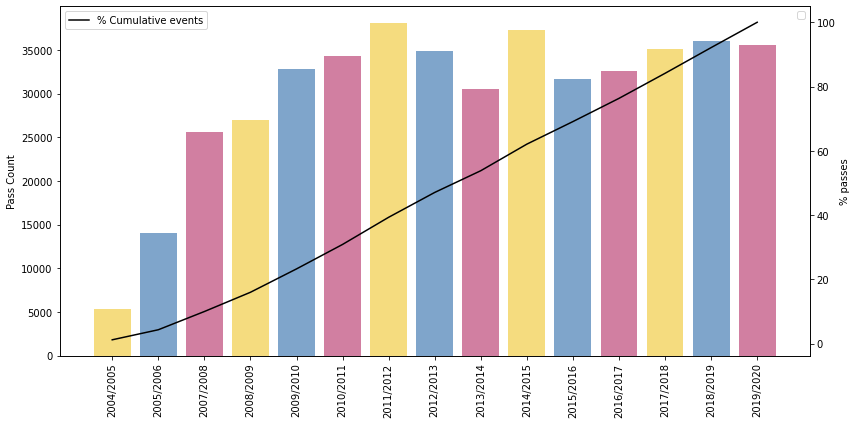

In [28]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.bar(season_event_counts.index, season_event_counts["event_count"], color=barca_colors,alpha=0.5)
ax.set_ylabel('Pass Count')


ax2.plot(season_event_counts.index, season_event_counts["%_events"], color='black', label='% Cumulative events')
ax2.set_ylabel('% passes')
ax.set_xticklabels(season_event_counts.index,rotation=90)

fig = plt.gcf()
fig.set_size_inches(12, 6)
plt.tight_layout()
plt.legend(loc='upper left')
ax.legend(loc='best')
plt.savefig('cumulative_season_events.png')

In [29]:
'''
train = passes_outcome_fin[passes_outcome_fin.season.isin(['2004/2005', '2005/2006', '2007/2008', '2008/2009', '2009/2010',
       '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015','2015/2016'])]
test = passes_outcome_fin[~passes_outcome_fin.season.isin(['2004/2005', '2005/2006', '2007/2008', '2008/2009', '2009/2010',
       '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015','2015/2016'])]

X_train = train.drop(['pass_outcome'],axis=1)
X_test = test.drop(['pass_outcome'],axis=1)
y_train = train['pass_outcome']
y_test = test['pass_outcome']

# Get rid of some of the last few columns that we have
X_train.drop(['player_id','player_name','season'],axis=1,inplace=True)
X_test.drop(['player_id','player_name','season'],axis=1,inplace=True)


'''

"\ntrain = passes_outcome_fin[passes_outcome_fin.season.isin(['2004/2005', '2005/2006', '2007/2008', '2008/2009', '2009/2010',\n       '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015','2015/2016'])]\ntest = passes_outcome_fin[~passes_outcome_fin.season.isin(['2004/2005', '2005/2006', '2007/2008', '2008/2009', '2009/2010',\n       '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015','2015/2016'])]\n\nX_train = train.drop(['pass_outcome'],axis=1)\nX_test = test.drop(['pass_outcome'],axis=1)\ny_train = train['pass_outcome']\ny_test = test['pass_outcome']\n\n# Get rid of some of the last few columns that we have\nX_train.drop(['player_id','player_name','season'],axis=1,inplace=True)\nX_test.drop(['player_id','player_name','season'],axis=1,inplace=True)\n\n\n"

In [30]:
# This is the more straightforward and robust way of splitting data

from sklearn.model_selection import train_test_split

features = passes_outcome_fin.drop(['pass_outcome'],axis=1)
target = passes_outcome_fin['pass_outcome']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=2021)

X_train_full = X_train.copy()
X_test_full = X_test.copy()

X_train.drop(['player_id','player_name','team_name','season'],axis=1,inplace=True)
X_test.drop(['player_id','player_name','team_name','season'],axis=1,inplace=True)
print(f"Train size: {X_train.shape[0]}\nTest size: {X_test.shape[0]}")

Train size: 315487
Test size: 135209


C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:4167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [31]:
X_train.head()

,pass_length,pass_angle,pass_start_x,pass_start_y,pass_end_x,pass_end_y,pass_height_name_Ground Pass,pass_height_name_High Pass,pass_height_name_Low Pass,pass_body_part_name_Drop Kick,pass_body_part_name_Head,pass_body_part_name_Keeper Arm,pass_body_part_name_Left Foot,pass_body_part_name_No Touch,pass_body_part_name_Other,pass_body_part_name_Right Foot,pass_type_name_Corner,pass_type_name_Free Kick,pass_type_name_Goal Kick,pass_type_name_Interception,pass_type_name_Kick Off,pass_type_name_Normal,pass_type_name_Recovery,pass_type_name_Throw-in,under_pressure_True,under_pressure_False,pass_switch_True,pass_switch_False,pass_outswinging_True,pass_outswinging_False,pass_through_ball_True,pass_through_ball_False,pass_inswinging_True,pass_inswinging_False,pass_no_touch_True,pass_no_touch_False,pass_cut_back_True,pass_cut_back_False,pass_straight_True,pass_straight_False,rel_x,rel_y
3230,20.038464,-0.686432,0.686258,0.374226,0.814570,0.216584,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0.128311,-0.157641
1977,8.602325,-2.521343,0.702815,0.197026,0.644868,0.134901,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,-0.057947,-0.062125
2474,13.708756,1.297507,0.246689,0.629492,0.277318,0.792079,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0.030629,0.162587
1499,29.068884,-1.107149,0.760762,0.903346,0.868377,0.580446,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0.107616,-0.322900
50,17.334936,-1.918089,0.326159,0.273854,0.277318,0.071782,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,-0.048841,-0.202072


## SKLearn Classifier Comparison
In order to understand what model is best, we need to compare a variety of different models. I've selected a number of SKLearn models, as well as XGBoost which is a popular classifier which generally performs well.

This piece goes through this range of models and performs N-fold cross validation of each model, and reports the average performance metric for each. As the data is very imbalanced, Accuracy is not considered. Instead we use Precision, Recall and [F1-score](https://en.wikipedia.org/wiki/F-score)

The following is adapted from a number of Kaggle pages, which I've collated and adapted overtime

In [119]:
# Define dictionary with performance metrics
scoring = {'precision':make_scorer(precision_score),
           'recall':make_scorer(recall_score), 
           'f1_score':make_scorer(f1_score)}


# Instantiate the machine learning classifiers
log_model = LogisticRegression(max_iter=100000)
svc_model = LinearSVC(dual=False)
dtr_model = DecisionTreeClassifier()
rfc_model = RandomForestClassifier()
xgb_model = XGBClassifier()

# Define the models evaluation function
def evaluate_models(X, y, folds):
    
    # Perform cross-validation to each machine learning classifier
    log = cross_validate(log_model, X, y, cv=folds, scoring=scoring)
    svc = cross_validate(svc_model, X, y, cv=folds, scoring=scoring)
    dtr = cross_validate(dtr_model, X, y, cv=folds, scoring=scoring)
    rfc = cross_validate(rfc_model, X, y, cv=folds, scoring=scoring)
    xgb = cross_validate(xgb_model, X, y, cv=folds, scoring=scoring)

    # Create a data frame with the models perfoamnce metrics scores
    models_scores_table = pd.DataFrame({'Logistic Regression':[log['test_precision'].mean(),
                                                               log['test_recall'].mean(),
                                                               log['test_f1_score'].mean()],
                                       
                                      'Support Vector Classifier':[svc['test_precision'].mean(),
                                                                   svc['test_recall'].mean(),
                                                                   svc['test_f1_score'].mean()],
                                       
                                      'Decision Tree':[dtr['test_precision'].mean(),
                                                       dtr['test_recall'].mean(),
                                                       dtr['test_f1_score'].mean()],
                                       
                                      'Random Forest':[rfc['test_precision'].mean(),
                                                       rfc['test_recall'].mean(),
                                                       rfc['test_f1_score'].mean()],
                                       
                                      'XGBoost':[xgb['test_precision'].mean(),
                                                              xgb['test_recall'].mean(),
                                                              xgb['test_f1_score'].mean()]},
                                      
                                      index=['Precision', 'Recall', 'F1 Score'])
    
    # Add 'Best Score' column
    models_scores_table['Best Score'] = models_scores_table.idxmax(axis=1)
    
    # Return models performance metrics scores data frame
    return(models_scores_table)
  


In [120]:
# Run models_evaluation function
results = evaluate_models(X_train, y_train, 5)

NameError: name 'cross_validate' is not defined

In [109]:
results.head()

,Logistic Regression,Support Vector Classifier,Decision Tree,Random Forest,XGBoost,Best Score
Precision,0.897975,0.889951,0.919356,0.920504,0.921915,XGBoost
Recall,0.974013,0.983700,0.913391,0.966392,0.969396,Support Vector Classifier
F1 Score,0.934442,0.934476,0.916358,0.942883,0.945053,XGBoost


## XGBoost hyperparameter search

In [103]:
params = {
        'learning_rate': [0.0001,0.001,0.01,0.1,1],
        'n_estimators': [200,400,600,800,1000,2000]
}

In [179]:
#pos_weight = 6.97 # If unsuccessful = 1
pos_weight = 0.144 # If success = 1

xgb_class = XGBClassifier(objective='binary:logistic',silent=True,scale_pos_weight=pos_weight, nthread=4)

In [105]:
folds = 3
param_comb = 5

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

#random_search = RandomizedSearchCV(xgb_class, param_distributions=params, n_iter=param_comb, scoring='roc_auc', n_jobs=4, cv=skf.split(X_train,y_train), verbose=3, random_state=1001 )
random_search = GridSearchCV(xgb_class, param_grid=params, scoring='roc_auc', n_jobs=4, cv=skf.split(X_train,y_train), verbose=3)


# Here we go
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 21.6min
[Parallel(n_jobs=4)]: Done  90 out of  90 | elapsed: 161.9min finished


[11:53:55] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




GridSearchCV(cv=<generator object _BaseKFold.split at 0x000001E8FB1B44A0>,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, gamma=None,
                                     gpu_id=None, importance_type='gain',
                                     interaction_constraints=None,
                                     learning_rate=None, max_delta_step=None,
                                     max_depth=None, min_child_weight=None,
                                     missing=n...
                                     n_estimators=100, n_jobs=None, nthread=4,
                                     num_parallel_tree=None, random_state=None,
                                     reg_alpha=None, reg_lambda=None,
                                     scale_pos_weight=6.97, silent=True,
                 

In [107]:
print('\n Best normalized gini score for %d-fold search with %d parameter combinations:' % (folds, param_comb))
print(random_search.best_score_ * 2 - 1)
print('\n Best hyperparameters:')
print(random_search.best_params_)
results = pd.DataFrame(random_search.cv_results_)


 Best normalized gini score for 3-fold search with 5 parameter combinations:
0.8062080209676861

 Best hyperparameters:
{'learning_rate': 0.01, 'n_estimators': 2000}


In [108]:
params = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

In [109]:
xgb_class = XGBClassifier(learning_rate = 0.01, n_estimators = 2000, scale_pos_weight=pos_weight, objective='binary:logistic',silent=True, nthread=4)
folds = 3
param_comb = 5

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

random_search = RandomizedSearchCV(xgb_class, param_distributions=params, n_iter=param_comb, scoring='roc_auc', n_jobs=4, cv=skf.split(X_train,y_train), verbose=3, random_state=1001 )

# Here we go
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed: 27.3min finished


[14:56:10] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




RandomizedSearchCV(cv=<generator object _BaseKFold.split at 0x000001E8FB1B4350>,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, gamma=None,
                                           gpu_id=None, importance_type='gain',
                                           interaction_constraints=None,
                                           learning_rate=0.01,
                                           max_delta_step=None, max_depth=None,
                                           min_child_weight=None, mis...
                                           random_state=None, reg_alpha=None,
                                           reg_lambda=None,
                                           scale_pos_weight=6.97, silent=True,
                                           subsa

In [110]:
print('\n Best normalized gini score for %d-fold search with %d parameter combinations:' % (folds, param_comb))
print(random_search.best_score_ * 2 - 1)
print('\n Best hyperparameters:')
print(random_search.best_params_)
results = pd.DataFrame(random_search.cv_results_)


 Best normalized gini score for 3-fold search with 5 parameter combinations:
0.8073457252516125

 Best hyperparameters:
{'subsample': 0.6, 'min_child_weight': 1, 'max_depth': 5, 'gamma': 1.5, 'colsample_bytree': 0.8}


## Train final XGBoost model
So we now use all of the parameters we've identified, as well as the scale_pos_weight value which we calculated earlier.

In [28]:
#pos_weight = 6.97 # If unsuccessful = 1
pos_weight = 0.144 # If success = 1

xgb_class = XGBClassifier(learning_rate = 0.01, 
                          n_estimators = 2000, 
                          subsample=0.6,
                          min_child_weight = 1,
                          max_depth = 5,
                          gamma = 1.5,
                          colsample_bytree = 0.8,
                          scale_pos_weight=pos_weight,
                          objective='binary:logistic', nthread=4)

In [184]:
xgb_class.fit(X_train,y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8, gamma=1.5, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.01, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=2000, n_jobs=4, nthread=4, num_parallel_tree=1,
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=0.144,
              subsample=0.6, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [185]:
y_pred = xgb_class.predict(X_test)
y_pred_probs = xgb_class.predict_proba(X_test)

In [186]:
print(classification_report(y_test, y_pred, target_names=['unsuccessful','successful']))

              precision    recall  f1-score   support

unsuccessful       0.41      0.82      0.55     16946
  successful       0.97      0.83      0.89    118263

    accuracy                           0.83    135209
   macro avg       0.69      0.83      0.72    135209
weighted avg       0.90      0.83      0.85    135209



In [187]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(y_test, y_pred)
print('Precision: %f' % precision)
recall = recall_score(y_test, y_pred)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, y_pred)
print('F1 score: %f' % f1)

Accuracy: 0.828584
Precision: 0.970462
Recall: 0.829262
F1 score: 0.894323


In [188]:
# kappa
kappa = cohen_kappa_score(y_test, y_pred)
print('Cohens kappa: %f' % kappa)
# ROC AUC
auc = roc_auc_score(y_test, y_pred)
print('ROC AUC: %f' % auc)
# confusion matrix
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Cohens kappa: 0.455147
ROC AUC: 0.826557
[[13961  2985]
 [20192 98071]]


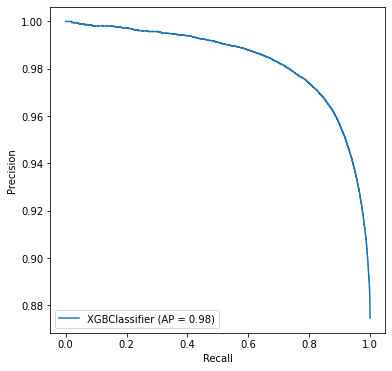

In [189]:
plot_precision_recall_curve(xgb_class, X_test, y_test)
fig = plt.gcf()
fig.set_size_inches(6, 6)
plt.savefig('prcurve.png')

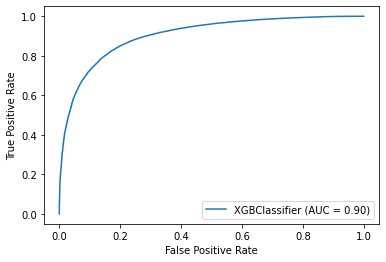

In [190]:
disp = plot_roc_curve(xgb_class, X_test, y_test)
plt.savefig('roccurve.png',dpi=600)

In [155]:
from numpy import arange
from numpy import argmax

# apply threshold to positive probabilities to create labels
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')

# keep probabilities for the positive outcome only
probs = y_pred_probs[:, 1]
# define thresholds
thresholds = arange(0, 1, 0.001)
# evaluate each threshold
scores = [f1_score(y_test, to_labels(probs, t)) for t in thresholds]
# get best threshold
ix = argmax(scores)
print('Threshold=%.3f, F-Score=%.5f' % (thresholds[ix], scores[ix]))

Threshold=0.736, F-Score=0.59761


In [200]:
results = pd.DataFrame(y_pred)
results.columns = ['class']
results['probability'] = None
results['probability'] = y_pred_probs[:,1]
results['new_class'] = np.where(results['probability'] > 0.2, 1, 0)
print(classification_report(y_test, results['new_class'], target_names=['unsuccessful','successful']))

              precision    recall  f1-score   support

unsuccessful       0.60      0.58      0.59     16946
  successful       0.94      0.94      0.94    118263

    accuracy                           0.90    135209
   macro avg       0.77      0.76      0.76    135209
weighted avg       0.90      0.90      0.90    135209



In [201]:
results.head()

,class,probability,new_class
0,1,0.940738,1
1,1,0.698881,1
2,0,0.019556,0
3,1,0.895252,1
4,1,0.675965,1


In [202]:
print(confusion_matrix(y_test, results['new_class']))

[[  9778   7168]
 [  6559 111704]]


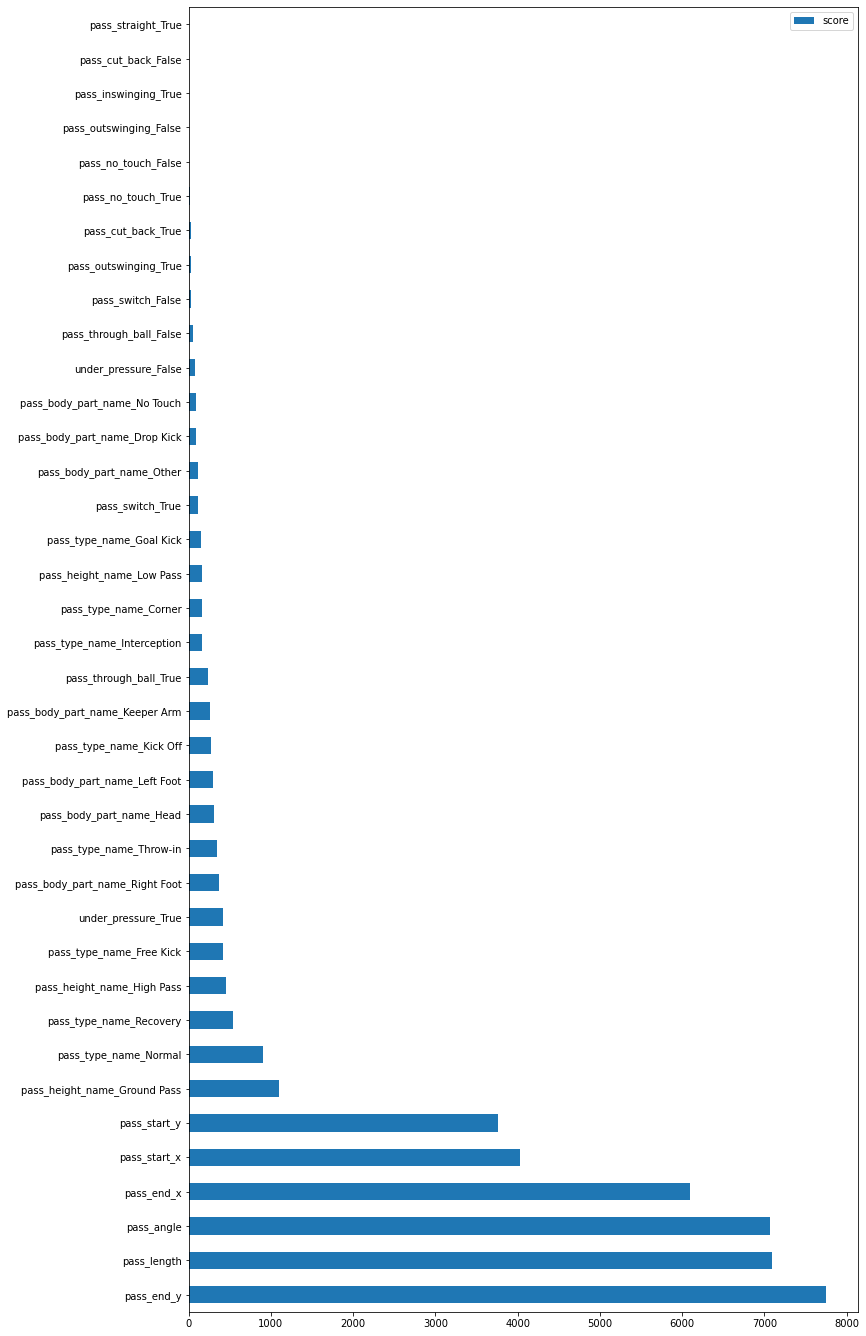

In [70]:
feature_important = xgb_class.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

importances = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
importances.plot(kind='barh')
fig = plt.gcf()
fig.set_size_inches(12, 24)

In [71]:
best_feats = list(importances.head(20).index)

Now lets see how well the model performs by training on all but the most recent season

I'll do this by making the training set include all but the 2019/20 season, while the test set will be 2019/20 season alone

In [243]:
train_L = passes_outcome_fin[~passes_outcome_fin.season.isin(['2019/2020'])]
test_L = passes_outcome_fin[passes_outcome_fin.season.isin(['2019/2020'])]

X_train_L = train_L.drop(['pass_outcome'],axis=1)
X_test_L = test_L.drop(['pass_outcome'],axis=1)
y_train_L = train_L['pass_outcome']
y_test_L = test_L['pass_outcome']

X_train_L.drop(['player_id','player_name','season'],axis=1,inplace=True)
X_test_L.drop(['player_id','player_name','season'],axis=1,inplace=True)

print(f"Train size: {X_train_L.shape[0]}\nTest size: {X_test_L.shape[0]}")

Train size: 415194
Test size: 35510


In [ ]:
xgb_class_larger_train = XGBClassifier(learning_rate = 0.01, 
                          n_estimators = 2000, 
                          subsample=0.6,
                          min_child_weight = 1,
                          max_depth = 5,
                          gamma = 1.5,
                          colsample_bytree = 0.8,
                          scale_pos_weight=pos_weight,
                          objective='binary:logistic',nthread=4)

In [248]:
xgb_class_larger_train.fit(X_train_L,y_train_L)

[16:35:21] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8, gamma=1.5, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.01, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=1000, n_jobs=1, nthread=1, num_parallel_tree=1,
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=0.144,
              silent=True, subsample=0.6, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [252]:
y_pred_L = xgb_class_larger_train.predict(X_test_L)
y_pred_probs_L = xgb_class_larger_train.predict_proba(X_test_L)

In [253]:
print(classification_report(y_test_L, y_pred_L, target_names=['successful','unsuccessful']))

              precision    recall  f1-score   support

unsuccessful       0.38      0.84      0.53      3893
  successful       0.98      0.83      0.90     31617

    accuracy                           0.83     35510
   macro avg       0.68      0.84      0.71     35510
weighted avg       0.91      0.83      0.86     35510



In [ ]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test_L, y_pred_L)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(y_test_L, y_pred_L)
print('Precision: %f' % precision)
recall = recall_score(y_test_L, y_pred_L)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test_L, y_pred_L)
print('F1 score: %f' % f1)

# kappa
kappa = cohen_kappa_score(y_test_L, y_pred_L)
print('Cohens kappa: %f' % kappa)
# ROC AUC
auc = roc_auc_score(y_test_L, y_pred_L)
print('ROC AUC: %f' % auc)
# confusion matrix
matrix = confusion_matrix(y_test_L, y_pred_L)
print(matrix)

#### As performance is poor, I want to experiment with changing the classification threshold
The following code enables that in a very basic way

In [194]:
results = pd.DataFrame(y_pred_L)
results.columns = ['class']
results['probability'] = None
results['probability'] = y_pred_probs_L[:,1]
results['new_class'] = np.where(results['probability'] > 0.75, 1, 0)
results.head()

NameError: name 'y_pred_L' is not defined

In [ ]:
print(classification_report(y_test_L, results['new_class'], target_names=['successful','unsuccessful']))

In [ ]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test_L, results['new_class'])
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(y_test_L, results['new_class'])
print('Precision: %f' % precision)
recall = recall_score(y_test_L, results['new_class'])
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test_L, results['new_class'])
print('F1 score: %f' % f1)

# kappa
kappa = cohen_kappa_score(y_test_L, results['new_class'])
print('Cohens kappa: %f' % kappa)
# ROC AUC
auc = roc_auc_score(y_test_L, results['new_class'])
print('ROC AUC: %f' % auc)
# confusion matrix
matrix = confusion_matrix(y_test_L, results['new_class'])
print(matrix)

#### Cross-validation

Let's check the robustness of our model using Cross Validiation


In [186]:
cv_features = passes_outcome_fin.drop(['pass_outcome','player_id','player_name','season'],axis=1)
cv_target = passes_outcome_fin['pass_outcome']



In [188]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

kfold = StratifiedKFold(n_splits=7, random_state=2021)
results = cross_val_score(xgb_class, cv_features, cv_target, cv=kfold, scoring='f1_weighted')
print("Weighted F1: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

[12:24:50] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[12:26:59] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[12:29:11] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings bu

In [190]:
kfold = StratifiedKFold(n_splits=10, random_state=2021)
results = cross_val_score(xgb_class, cv_features, cv_target, cv=kfold, scoring='precision')
print("Precision: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

C:\Users\matth\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(


Precision: 96.99% (0.21%)


In [191]:
results = cross_val_score(xgb_class, cv_features, cv_target, cv=kfold, scoring='recall')
print("Recall: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Recall: 82.48% (1.00%)


## MLP
I want to experiment with using deep learning to perform the classification. 

In [74]:
X_train = X_train[best_feats]
X_test = X_test[best_feats]

X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

X_train_raw = X_train.values
print(X_train_raw.shape)
y_train_raw = tf.one_hot(y_train, depth=2)
print(y_train_raw.shape)

(315487, 20)
(315487, 2)


In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten
import tensorflow as tf
# Parameters
batch_size = 1280 # It is the sample size of inputs to be processed at each training stage. 
hidden_units = 512
dropout = 0.45
input_size = X_train_raw.shape[1]
num_labels = len(list(y_train.unique()))

# Nossa  MLP com ReLU e Dropout 
model = Sequential()

model.add(Dense(256, input_dim=input_size))
model.add(Activation('relu'))
model.add(Dropout(dropout))

model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(dropout))

model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(dropout))

model.add(Dense(num_labels))

model.add(Activation('softmax'))
#model.add(Flatten())
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 256)               5376      
_________________________________________________________________
activation (Activation)      (None, 256)               0         
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 512)               131584    
_________________________________________________________________
activation_1 (Activation)    (None, 512)               0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 256)               1

In [76]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['Precision','Recall'])
model.fit(X_train_raw, y_train_raw, epochs=20, batch_size=batch_size)

Epoch 1/20
247/247 [==============================] - 6s 21ms/step - loss: 0.3498 - precision: 0.8741 - recall: 0.8741
Epoch 2/20
247/247 [==============================] - 6s 22ms/step - loss: 0.2794 - precision: 0.8827 - recall: 0.8827
Epoch 3/20
247/247 [==============================] - 5s 21ms/step - loss: 0.2709 - precision: 0.8866 - recall: 0.8866
Epoch 4/20
247/247 [==============================] - 5s 21ms/step - loss: 0.2675 - precision: 0.8879 - recall: 0.8879
Epoch 5/20
247/247 [==============================] - 5s 21ms/step - loss: 0.2653 - precision: 0.8890 - recall: 0.8890
Epoch 6/20
247/247 [==============================] - 5s 21ms/step - loss: 0.2638 - precision: 0.8900 - recall: 0.8900
Epoch 7/20
247/247 [==============================] - 5s 21ms/step - loss: 0.2625 - precision: 0.8907 - recall: 0.8907
Epoch 8/20
247/247 [==============================] - 5s 21ms/step - loss: 0.2612 - precision: 0.8910 - recall: 0.8910
Epoch 9/20
247/247 [============================

In [77]:
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)

X_test_raw = X_test.values
y_test_raw = tf.one_hot(y_test, depth=2)

scores = model.evaluate(X_test_raw,
                        y_test_raw,
                        batch_size=batch_size,
                        verbose=0)

preds = model.predict(X_test_raw,
                      batch_size=batch_size,
                        verbose=0)
results = pd.DataFrame(preds,columns=['class0','class1'])
results['pred'] = np.where(results['class1'] > 0.2,1.0,0.0 )
results['class'] = y_test.values

print('Precision',precision_score(results['class'],results['pred']))
print('Recall',recall_score(results['class'],results['pred']))

Precision 0.8812212806588291
Recall 0.9989007550966913


## Using model to assess player performance

In [31]:
#pos_weight = 6.97 # If unsuccessful = 1
pos_weight = 0.144 # If success = 1

xgb_class_larger_train = XGBClassifier(learning_rate = 0.01, 
                          n_estimators = 1000, 
                          subsample=0.6,
                          min_child_weight = 1,
                          max_depth = 5,
                          gamma = 1.5,
                          colsample_bytree = 0.8,
                          scale_pos_weight=pos_weight,
                          objective='binary:logistic',silent=True, nthread=1)

In [32]:
xgb_class_larger_train.fit(X_train,y_train)

[16:32:14] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8, gamma=1.5, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.01, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=1000, n_jobs=1, nthread=1, num_parallel_tree=1,
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=0.144,
              silent=True, subsample=0.6, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [33]:
y_pred = xgb_class_larger_train.predict(X_test)
y_pred_proba = xgb_class_larger_train.predict_proba(X_test)

In [88]:
player_perf = X_test_full.copy()
player_perf['pass_outcome'] = y_test
player_perf['prediction'] = y_pred
player_perf['prob'] = y_pred_proba[:,1]
player_perf['new_prediction'] = np.where(player_perf['prob'] > 0.2, 1, 0)
player_perf['expected_pass_comp'] = player_perf['pass_outcome']-player_perf['prob']
player_perf.head()

,season,player_id,player_name,team_name,pass_length,pass_angle,pass_start_x,pass_start_y,pass_end_x,pass_end_y,pass_height_name_Ground Pass,pass_height_name_High Pass,pass_height_name_Low Pass,pass_body_part_name_Drop Kick,pass_body_part_name_Head,pass_body_part_name_Keeper Arm,pass_body_part_name_Left Foot,pass_body_part_name_No Touch,pass_body_part_name_Other,pass_body_part_name_Right Foot,pass_type_name_Corner,pass_type_name_Free Kick,pass_type_name_Goal Kick,pass_type_name_Interception,pass_type_name_Kick Off,pass_type_name_Normal,pass_type_name_Recovery,pass_type_name_Throw-in,under_pressure_True,under_pressure_False,pass_switch_True,pass_switch_False,pass_outswinging_True,pass_outswinging_False,pass_through_ball_True,pass_through_ball_False,pass_inswinging_True,pass_inswinging_False,pass_no_touch_True,pass_no_touch_False,pass_cut_back_True,pass_cut_back_False,pass_straight_True,pass_straight_False,rel_x,rel_y,pass_outcome,prediction,prob,new_prediction,expected_pass_comp
2747,2017/2018,6609.0,Denis Suárez Fernández,Barcelona,15.811388,-2.176341,0.694536,0.940520,0.620033,0.778465,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,-0.074503,-0.162055,1,1,0.928735,1,0.071265
3091,2017/2018,5737.0,"Steven N""Kemboanza Mike Christopher Nzonzi",Sevilla,10.770329,-0.380506,0.413079,0.804213,0.495861,0.753713,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0.082781,-0.050500,0,1,0.716150,1,-0.716150
687,2007/2008,25924.0,José Maria Gutiérrez Hernández,Real Madrid,54.664250,1.060499,0.606788,0.399009,0.827815,0.988861,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0.221026,0.589853,0,0,0.032285,0,-0.032285
1725,2018/2019,8206.0,Arturo Erasmo Vidal Pardo,Barcelona,20.248457,-1.217806,0.528974,0.432466,0.586921,0.196782,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0.057947,-0.235684,1,1,0.875563,1,0.124437
3792,2014/2015,5470.0,Ivan Rakitić,Barcelona,16.154875,0.427652,0.399007,0.140025,0.520695,0.222772,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0.121689,0.082747,1,1,0.681764,1,0.318236


In [106]:
player_perf_results = player_perf.groupby(['player_name','team_name'])['pass_outcome','new_prediction','expected_pass_comp'].agg({'pass_outcome':['count','sum'],
                                                                     'new_prediction':'sum','expected_pass_comp':'sum'})
player_perf_results.columns = player_perf_results.columns.droplevel(0)
player_perf_results.reset_index(inplace=True)
player_perf_results.columns = ['player_name','team_name','pass_att_count','actual_pass_comp','pred_pass_comp','PCR_sum']
player_perf_results['PCR_per_100_passes'] = player_perf_results['PCR_sum'] / (player_perf_results['pass_att_count']/100)
#player_perf_results['actual_pass_comp_%'] = (player_perf_results['actual_pass_comp']/player_perf_results['pass_att_count'])*100
#player_perf_results['pred_pass_comp_%'] = (player_perf_results['pred_pass_comp']/player_perf_results['pass_att_count'])*100
#player_perf_results['pred_pass_comp_comparison'] = player_perf_results['pred_pass_comp_%']-player_perf_results['actual_pass_comp_%']
#player_perf_results[player_perf_results.pass_att_count > 100].sort_values(by='pred_pass_comp_comparison',ascending=False).head(20)
player_perf_results[(player_perf_results.pass_att_count > 100) & (player_perf_results.team_name != 'Barcelona')].sort_values(by='PCR_per_100_passes',ascending=True).head(50)

<ipython-input-106-89773075fb47>:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  player_perf_results = player_perf.groupby(['player_name','team_name'])['pass_outcome','new_prediction','expected_pass_comp'].agg({'pass_outcome':['count','sum'],


,player_name,team_name,pass_att_count,actual_pass_comp,pred_pass_comp,PCR_sum,PCR_per_100_passes
2384,"Steven N""Kemboanza Mike Christopher Nzonzi",Sevilla,103,89,94,13.252529,12.866533
454,Cristiano Ronaldo dos Santos Aveiro,Real Madrid,131,99,105,17.086499,13.043129
1681,Manuel Trigueros Muñoz,Villarreal,108,87,93,15.081839,13.964665
2163,Roberto Trashorras Gayoso,Rayo Vallecano,119,104,107,16.835506,14.147484
1749,Markel Susaeta Laskurain,Athletic Bilbao,151,129,133,25.204833,16.691942
182,Ander Iturraspe Derteano,Athletic Bilbao,137,114,118,24.433899,17.834963
290,Asier Illarramendi Andonegi,Real Sociedad,117,107,104,21.409407,18.298639
2341,Sergio Ramos García,Real Madrid,248,210,212,46.663346,18.815865
1560,Kléper Laveran Lima Ferreira,Real Madrid,112,94,94,21.471480,19.170964
2274,Santiago Cazorla González,Villarreal,105,88,98,20.139104,19.180099


In [103]:
player_perf_results[player_perf_results.team_name != 'Barcelona'].sort_values(by='pass_att_count',ascending=False).head(15)

,player_name,team_name,pass_att_count,actual_pass_comp,pred_pass_comp,PCR_sum,PCR_per_100_passes
1704,Marcelo Vieira da Silva Júnior,Real Madrid,250,204,202,60.968790,24.387516
2341,Sergio Ramos García,Real Madrid,248,210,212,46.663346,18.815865
1317,Jorge Resurrección Merodio,Atlético Madrid,216,180,176,45.390999,21.014351
2431,Toni Kroos,Real Madrid,201,191,188,45.189199,22.482188
484,Daniel Carvajal Ramos,Real Madrid,185,162,157,39.391001,21.292433
1640,Luka Modrić,Real Madrid,178,159,160,38.389818,21.567313
352,Bruno Soriano Llido,Villarreal,173,156,163,35.294343,20.401354
1209,Jesús Navas González,Sevilla,163,127,130,32.818235,20.133886
2630,Óscar de Marcos Arana,Athletic Bilbao,162,131,127,37.096741,22.899223
499,Daniel Parejo Muñoz,Valencia,161,139,141,32.810129,20.378962


In [37]:
player_perf_results[player_perf_results.pass_att_count > 100].sort_values(by='pass_att_count',ascending=False).head(20)

,player_name,pass_att_count,actual_pass_comp,pred_pass_comp,actual_pass_comp_%,pred_pass_comp_%,pred_pass_comp_comparison
1624,Sergio Busquets i Burgos,7095,6614,6752,93.220578,95.165610,1.945032
1101,Lionel Andrés Messi Cuccittini,7093,6054,6113,85.351755,86.183561,0.831806
1767,Xavier Hernández Creus,6212,5775,5798,92.965229,93.335480,0.370251
647,Gerard Piqué Bernabéu,5808,5440,5431,93.663912,93.508953,-0.154959
142,Andrés Iniesta Luján,5384,4873,4957,90.508915,92.069094,1.560178
332,Daniel Alves da Silva,4966,4328,4393,87.152638,88.461538,1.308901
895,Jordi Alba Ramos,4267,3853,3871,90.297633,90.719475,0.421842
802,Javier Alejandro Mascherano,3443,3241,3212,94.133024,93.290735,-0.842289
759,Ivan Rakitić,3355,3071,3095,91.535022,92.250373,0.715350
1619,Sergi Roberto Carnicer,2483,2320,2303,93.435360,92.750705,-0.684656


In [38]:
player_perf_results[player_perf_results.pass_att_count > 500].sort_values(by='pred_pass_comp_%',ascending=False).head(20)

,player_name,pass_att_count,actual_pass_comp,pred_pass_comp,actual_pass_comp_%,pred_pass_comp_%,pred_pass_comp_comparison
198,Arthur Henrique Ramos de Oliveira Melo,615,582,591,94.634146,96.097561,1.463415
1690,Thiago Alcântara do Nascimento,1123,1050,1079,93.499555,96.081923,2.582369
662,Gnégnéri Yaya Touré,973,907,934,93.216855,95.991778,2.774923
1624,Sergio Busquets i Burgos,7095,6614,6752,93.220578,95.165610,1.945032
1589,Samuel Yves Umtiti,1416,1335,1342,94.279661,94.774011,0.494350
250,Carles Puyol i Saforcada,2315,2176,2192,93.995680,94.686825,0.691145
1178,Marc Bartra Aregall,587,563,554,95.911414,94.378194,-1.533220
1357,Nélson Cabral Semedo,1069,979,1008,91.580917,94.293732,2.712816
1653,Seydou Kéita,1120,1039,1053,92.767857,94.017857,1.250000
647,Gerard Piqué Bernabéu,5808,5440,5431,93.663912,93.508953,-0.154959


In [39]:
player_perf_results[player_perf_results.pass_att_count > 500].sort_values(by='pred_pass_comp_%',ascending=True).head(20)

,player_name,pass_att_count,actual_pass_comp,pred_pass_comp,actual_pass_comp_%,pred_pass_comp_%,pred_pass_comp_comparison
1127,Luis Alberto Suárez Díaz,1426,1126,1171,78.962132,82.117812,3.155680
1750,Víctor Valdés Arribas,1611,1386,1342,86.033520,83.302297,-2.731223
296,Claudio Andrés Bravo Muñoz,560,502,474,89.642857,84.642857,-5.000000
129,Anderson Luís de Souza,636,527,545,82.861635,85.691824,2.830189
1101,Lionel Andrés Messi Cuccittini,7093,6054,6113,85.351755,86.183561,0.831806
1340,Neymar da Silva Santos Junior,1530,1271,1320,83.071895,86.274510,3.202614
107,Alexis Alejandro Sánchez Sánchez,592,484,513,81.756757,86.655405,4.898649
1189,Marc-André ter Stegen,1255,1132,1090,90.199203,86.852590,-3.346614
332,Daniel Alves da Silva,4966,4328,4393,87.152638,88.461538,1.308901
1429,Pedro Eliezer Rodríguez Ledesma,1594,1379,1429,86.511920,89.648683,3.136763


In [40]:
player_perf_results['over_under'] = np.where(player_perf_results['pred_pass_comp_comparison']>=0,'Over','Under')
player_perf_results['over_under'].value_counts()

Over     1316
Under     527
Name: over_under, dtype: int64

## Playing with summing probability

In [94]:
player_perf_results = player_perf.groupby('player_name')['pass_outcome','prediction','prob','expected_pass_comp'].agg({'pass_outcome':['count','sum'],
                                                                     'prediction':'sum',
                                                                     'prob':['sum','mean'],
                                                                     'expected_pass_comp':'sum'})
player_perf_results.columns = player_perf_results.columns.droplevel(0)
player_perf_results.reset_index(inplace=True)
player_perf_results.columns = ['player_name','pass_att_count','actual_pass_comp','pred_pass_comp','prob_pass_comp_sum','prob_pass_comp_avg','ex_pass_sum']
player_perf_results['actual_pass_comp_%'] = (player_perf_results['actual_pass_comp']/player_perf_results['pass_att_count'])*100
player_perf_results['prob_pass_comp_%'] = (player_perf_results['prob_pass_comp_sum']/player_perf_results['pass_att_count'])*100
player_perf_results['prob_pass_comp_comparison'] = player_perf_results['prob_pass_comp_%']-player_perf_results['actual_pass_comp_%']
player_perf_results['ex_pass_per_100pass'] = player_perf_results['ex_pass_sum']/(player_perf_results['pass_att_count']/100)

player_perf_results[player_perf_results.pass_att_count > 250].sort_values(by='ex_pass_per_100pass',ascending=False).head()

<ipython-input-94-cf745e62a33f>:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  player_perf_results = player_perf.groupby('player_name')['pass_outcome','prediction','prob','expected_pass_comp'].agg({'pass_outcome':['count','sum'],


,player_name,pass_att_count,actual_pass_comp,pred_pass_comp,prob_pass_comp_sum,prob_pass_comp_avg,ex_pass_sum,actual_pass_comp_%,prob_pass_comp_%,prob_pass_comp_comparison,ex_pass_per_100pass
1101,Lionel Andrés Messi Cuccittini,7093,6054,4600,4368.501465,0.615889,1685.498563,85.351755,61.588911,-23.762844,23.762845
152,Antoine Griezmann,410,342,259,246.118713,0.600290,95.881281,83.414634,60.028954,-23.385680,23.385678
1543,Ronaldo de Assis Moreira,433,351,254,252.487747,0.583113,98.512247,81.062356,58.311258,-22.751098,22.751096
184,Arda Turan,417,371,294,277.173950,0.664686,93.826063,88.968825,66.468573,-22.500252,22.500255
1340,Neymar da Silva Santos Junior,1530,1271,987,948.532593,0.619956,322.467408,83.071895,61.995594,-21.076301,21.076301


In [80]:
player_perf_results[player_perf_results.pass_att_count > 500].sort_values(by='prob_pass_comp_avg',ascending=False).head()

,player_name,pass_att_count,actual_pass_comp,pred_pass_comp,prob_pass_comp_sum,prob_pass_comp_avg,actual_pass_comp_%,prob_pass_comp_%,prob_pass_comp_comparison
662,Gnégnéri Yaya Touré,973,907,853,767.609985,0.788911,93.216855,78.891057,-14.325798
1178,Marc Bartra Aregall,587,563,515,456.775543,0.778153,95.911414,77.815254,-18.096160
250,Carles Puyol i Saforcada,2315,2176,1971,1776.342407,0.767319,93.995680,76.731853,-17.263827
1589,Samuel Yves Umtiti,1416,1335,1222,1086.304199,0.767164,94.279661,76.716398,-17.563263
647,Gerard Piqué Bernabéu,5808,5440,4962,4425.469238,0.761961,93.663912,76.196096,-17.467816
